# Titanic Survival Prediction - Decision Tree, Random Forest & Logistic Regression

#### Import the libraries

In [387]:
import pandas as pd
import numpy as np

### Load the dataset

In [388]:
train=pd.read_csv(r'train.csv')
test=pd.read_csv(r'test.csv')

#### Check that they loaded correctly

In [389]:
print('train shape',train.shape)
print('test shape',test.shape)

train shape (891, 12)
test shape (418, 11)


In [390]:
#Look at the first few passengers
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [391]:
# Check the columns
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [392]:
#The targwt column
train["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

### Count missing values

In [393]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [394]:
#Look at the numerical statistics
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [395]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [396]:
#survival by gender
train.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [397]:
#survival by Pclass
train.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [398]:
train.groupby(['Sex','Pclass'])['Survived'].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

In [399]:
train['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [400]:
train.groupby('Survived')['Age'].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

<Axes: title={'center': 'Survival Count'}, xlabel='Survived'>

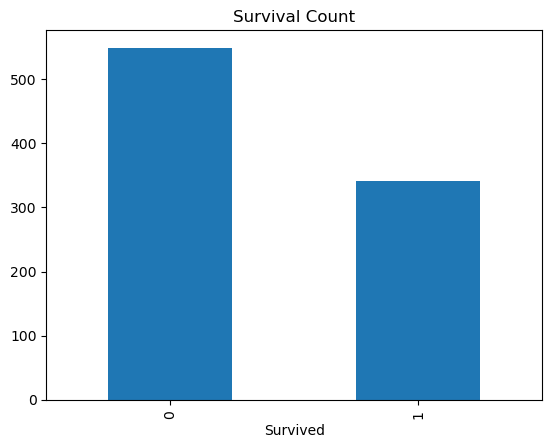

In [401]:
#Looking at the target variable
train['Survived'].value_counts().plot(kind='bar',title='Survival Count')

#### making copies of original data

In [402]:
train_copy=train.copy()
test_copy=test.copy()

### Dealing with missing values

In [403]:
# Deal with missing Age
print('missing values in train are:',train_copy["Age"].isnull().sum())
print('missing values in test are:',test_copy['Age'].isnull().sum())

missing values in train are: 177
missing values in test are: 86


In [404]:
Age_median=train_copy['Age'].median()
train_copy['Age']=train_copy['Age'].fillna(Age_median).astype(int)
test_copy['Age']=test_copy['Age'].fillna(Age_median).astype(int)

In [405]:
print('missing values in train are:',train_copy["Age"].isnull().sum())
print('missing values in test are:',test_copy['Age'].isnull().sum())

missing values in train are: 0
missing values in test are: 0


#### Dealing with missing Embarked

In [406]:
print('Number of missing values in train[Emarked] are:',train_copy['Embarked'].isnull().sum())
print('Number of missing values in test[Emarked] are:',test_copy['Embarked'].isnull().sum())

Number of missing values in train[Emarked] are: 2
Number of missing values in test[Emarked] are: 0


In [407]:
train_copy['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [408]:
train_copy['Embarked']=train_copy['Embarked'].fillna('S')
test_copy['Embarked']=test_copy['Embarked'].fillna('S')

In [409]:
print('Number of missing values in Emarked are:',train_copy['Embarked'].isnull().sum())

Number of missing values in Emarked are: 0


#### Dealing with missing Cabin

In [410]:
print('missing values in train[Cabin] are:',train_copy["Cabin"].isnull().sum())
print('missing values in test[Cabin] are:',test_copy['Cabin'].isnull().sum())

missing values in train[Cabin] are: 687
missing values in test[Cabin] are: 327


In [411]:
train_copy=train_copy.drop('Cabin',axis=1)
test_copy=test_copy.drop('Cabin',axis=1)

### Remove columns we don't need for our first model

In [412]:
train_copy=train_copy.drop(['PassengerId','Name','Ticket'],axis=1)

In [413]:
test_copy=test_copy.drop(['PassengerId','Name','Ticket'],axis=1)

In [414]:
train_copy.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22,1,0,7.2500,S
1,1,1,female,38,1,0,71.2833,C
2,1,3,female,26,0,0,7.9250,S
3,1,1,female,35,1,0,53.1000,S
4,0,3,male,35,0,0,8.0500,S


### Convert categorical variables

In [415]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [416]:
train_copy['Sex']=train_copy['Sex'].map({'male':0,'female':1})

In [417]:
test_copy['Sex']=test_copy['Sex'].map({'male':0,'female':1})

In [418]:
train_copy

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22,1,0,7.2500,S
1,1,1,1,38,1,0,71.2833,C
2,1,3,1,26,0,0,7.9250,S
3,1,1,1,35,1,0,53.1000,S
4,0,3,0,35,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,0,27,0,0,13.0000,S
887,1,1,1,19,0,0,30.0000,S
888,0,3,1,28,1,2,23.4500,S
889,1,1,0,26,0,0,30.0000,C


#### Convert Embarked

In [419]:
train_copy['Embarked']=train_copy['Embarked'].map({'C':0,'S':1,'Q':2})
test_copy['Embarked']=test_copy['Embarked'].map({'C':0,'S':1,'Q':2})

In [420]:
train_copy.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
184,1,3,1,4,0,2,22.025,1
513,1,1,1,54,1,0,59.400,0
501,0,3,1,21,0,0,7.750,2
316,1,2,1,24,1,0,26.000,1
657,0,3,1,32,1,1,15.500,2


##### Check for remaining missing values

In [421]:
train_copy.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [422]:
test_copy.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        1
Embarked    0
dtype: int64

### Create X and y

In [423]:
X=train_copy.drop('Survived',axis=1)

In [424]:
y=train_copy['Survived']

In [425]:
print('Shape of X is:',X.shape)
print('Shape of y is:',y.shape)

Shape of X is: (891, 7)
Shape of y is: (891,)


In [426]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22,1,0,7.2500,1
1,1,1,38,1,0,71.2833,0
2,3,1,26,0,0,7.9250,1
3,1,1,35,1,0,53.1000,1
4,3,0,35,0,0,8.0500,1


In [427]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

### Create X_test and y_test

In [428]:
X_test=test_copy

In [429]:
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,34,0,0,7.8292,2
1,3,1,47,1,0,7.0000,1
2,2,0,62,0,0,9.6875,2
3,3,0,27,0,0,8.6625,1
4,3,1,22,1,1,12.2875,1
...,...,...,...,...,...,...,...
413,3,0,28,0,0,8.0500,1
414,1,1,39,0,0,108.9000,0
415,3,0,38,0,0,7.2500,1
416,3,0,28,0,0,8.0500,1


### Training vs. Validation

In [430]:
from sklearn.model_selection import train_test_split

In [431]:
X_train,X_valid,y_train,y_valid=train_test_split(X,y,test_size=0.2,random_state=40,stratify=y)

##### check the sizes

In [432]:
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (712, 7)
X_valid: (179, 7)
y_train: (712,)
y_valid: (179,)


#### Check the survival proportions

In [433]:
print('Training_survival_rate for y_train:',y_train.mean())
print('Training_survival_rate for y_valid:',y_valid.mean())

Training_survival_rate for y_train: 0.38342696629213485
Training_survival_rate for y_valid: 0.3854748603351955


##### The two numbers should be fairly close. As we have used stratify=y

### Baseline Accuracy

In [434]:
from sklearn.metrics import accuracy_score 

In [435]:
baseline_predictions=[0]*len(y_valid)
baseline_accuracy=accuracy_score(baseline_predictions,y_valid)
print('Baseline accuracy is:',baseline_accuracy)

Baseline accuracy is: 0.6145251396648045


## Train a Decision Tree

In [436]:
from sklearn.tree import DecisionTreeClassifier

In [437]:
model=DecisionTreeClassifier(max_depth=5,random_state=40)

In [438]:
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,40
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


##### Make predictions on validation data

In [439]:
y_pred=model.predict(X_valid)

#### Measure accuracy

In [440]:
accuracy=accuracy_score(y_pred,y_valid)
print('Validation Accuracy:',accuracy)

Validation Accuracy: 0.8547486033519553


In [441]:
print("Baseline accuracy:", baseline_accuracy)
print("Decision Tree accuracy:", accuracy)


Baseline accuracy: 0.6145251396648045
Decision Tree accuracy: 0.8547486033519553


In [442]:
from sklearn.metrics import confusion_matrix

In [443]:
cm=confusion_matrix(y_valid,y_pred)
print(cm)

[[102   8]
 [ 18  51]]


#### Visualizing confusion matrix

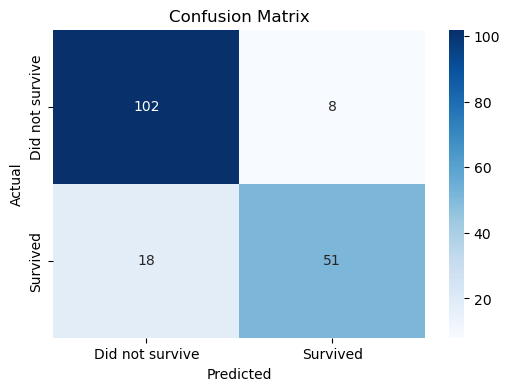

In [444]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did not survive", "Survived"],
    yticklabels=["Did not survive", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


### Generate a classification report

In [445]:
from sklearn.metrics import classification_report
print(classification_report(y_valid,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.93      0.89       110
           1       0.86      0.74      0.80        69

    accuracy                           0.85       179
   macro avg       0.86      0.83      0.84       179
weighted avg       0.86      0.85      0.85       179



#### Check for overfitting

In [446]:
train_pred=model.predict(X_train)
train_accuracy=accuracy_score(train_pred,y_train)
print('Training Accuracy:',train_accuracy)
print('Validation Accuracy:',accuracy)

Training Accuracy: 0.8398876404494382
Validation Accuracy: 0.8547486033519553


### Check feature importance

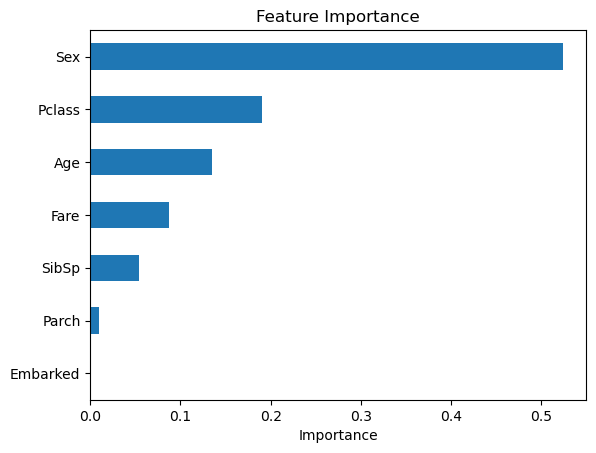

In [447]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)
feature_importance.sort_values().plot(
    kind="barh",
    title="Feature Importance"
)

plt.xlabel("Importance")
plt.show()

## Try Better Models

We'll test:

1. Logistic Regression
2. Random Forest
3. A few Decision Tree depths

Then we'll compare their validation accuracy.

In [448]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#### Try Logistic Regression

In [449]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_valid)

log_accuracy = accuracy_score(
    y_valid,
    log_pred
)

#### Try Random Forest


In [450]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_valid)

rf_accuracy = accuracy_score(
    y_valid,
    rf_pred
)

#### Train the Random Forest

In [451]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_valid)

rf_accuracy = accuracy_score(
    y_valid,
    rf_pred
)

### Compare our models

In [452]:
print("Baseline:", baseline_accuracy)
print("Decision Tree:", accuracy)
print("Logistic Regression:", log_accuracy)
print("Random Fores:", rf_accuracy)

Baseline: 0.6145251396648045
Decision Tree: 0.8547486033519553
Logistic Regression: 0.8100558659217877
Random Fores: 0.8379888268156425


### Compare the models visually

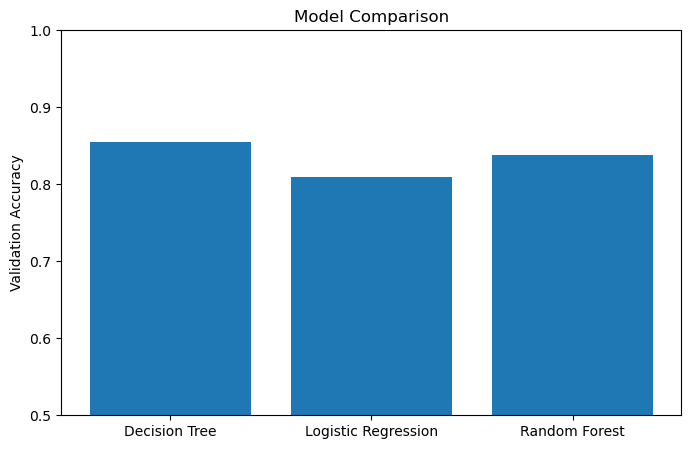

In [453]:
models = [
    "Decision Tree",
    "Logistic Regression",
    "Random Forest"
]

scores = [
    accuracy,
    log_accuracy,
    rf_accuracy
]

plt.figure(figsize=(8, 5))

plt.bar(models, scores)

plt.ylim(0.5, 1.0)

plt.ylabel("Validation Accuracy")
plt.title("Model Comparison")

plt.show()


# Train the Final Model and Predict the X_test

#### Check the Decision Tree's training accuracy

In [454]:
tree_train_pred = model.predict(X_train)

tree_train_accuracy = accuracy_score(
    y_train,
    tree_train_pred
)

print("Decision Tree training accuracy:", tree_train_accuracy)
print("Decision Tree validation accuracy:", accuracy)


Decision Tree training accuracy: 0.8398876404494382
Decision Tree validation accuracy: 0.8547486033519553


In [455]:
final_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)


In [456]:
final_model.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


##### Predict the 418 unknown passengers

In [457]:
test_predictions = final_model.predict(X_test)
print("Number of predictions:", len(test_predictions))

Number of predictions: 418


#### Get the Passenger IDs

In [458]:
passenger_ids = test["PassengerId"]

#### Create the submission DataFrame

In [459]:
submission = pd.DataFrame({"PassengerId": passenger_ids,"Survived": test_predictions})

In [460]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [461]:
print("Shape:", submission.shape)
print("Columns:", list(submission.columns))
print("Missing values:")
print(submission.isnull().sum())

Shape: (418, 2)
Columns: ['PassengerId', 'Survived']
Missing values:
PassengerId    0
Survived       0
dtype: int64


#### Save the CSV

In [462]:
submission.to_csv(
    "submission.csv",
    index=False)

In [463]:
submission = pd.read_csv("submission.csv")

print(submission.head())
print("Rows:", len(submission))

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
Rows: 418


### Conclusion
In this project, I developed a machine learning workflow for predicting Titanic passenger survival.

The process included data exploration, missing-value handling, categorical encoding, feature selection, training/validation splitting, and comparison of multiple classification models.

The models evaluated were:

##### Decision Tree - 85.47% validation accuracy

##### Random Forest - 83.80% validation accuracy

##### Logistic Regression - 81.01% validation accuracy

##### Baseline - 61.45% validation accuracy

The Decision Tree achieved the highest validation accuracy among the models tested, so I used it for the final submission.